Valid area: 5.86e-13 m^2
Unit cell area: 8.99e-13 m^2
Valid area / Unit cell area: 0.652
Initial density: 1.71e+12 centers/m^2

Simulating for density: 5.00e+11 centers/m^2
Density: 5.00e+11 -> Probability (exactly 1 valid): 0.173

Simulating for density: 5.25e+11 centers/m^2
Density: 5.25e+11 -> Probability (exactly 1 valid): 0.181

Simulating for density: 5.51e+11 centers/m^2
Density: 5.51e+11 -> Probability (exactly 1 valid): 0.188

Simulating for density: 5.76e+11 centers/m^2
Density: 5.76e+11 -> Probability (exactly 1 valid): 0.194

Simulating for density: 6.01e+11 centers/m^2
Density: 6.01e+11 -> Probability (exactly 1 valid): 0.200

Simulating for density: 6.26e+11 centers/m^2
Density: 6.26e+11 -> Probability (exactly 1 valid): 0.209

Simulating for density: 6.52e+11 centers/m^2
Density: 6.52e+11 -> Probability (exactly 1 valid): 0.213

Simulating for density: 6.77e+11 centers/m^2
Density: 6.77e+11 -> Probability (exactly 1 valid): 0.218

Simulating for density: 7.02e+11 centers

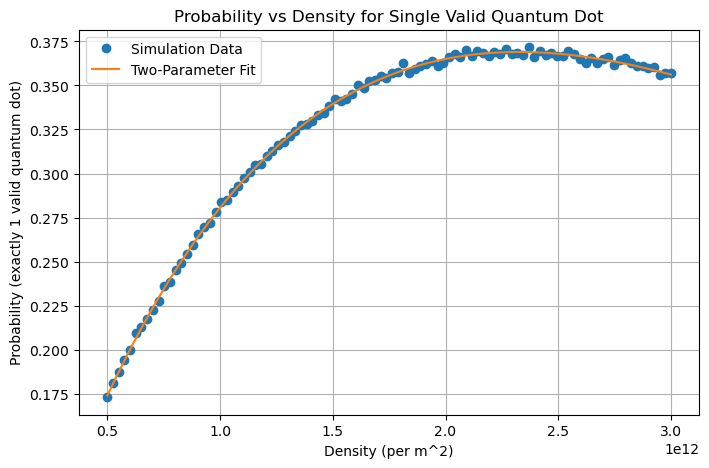


Fitted parameters:
alpha = 4.314e-13
beta  = 4.301e-13
Peak of fitted curve at density ~ 2.325e+12 per m^2


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

##############################################################################
# 1. GEOMETRY AND VALIDITY FUNCTIONS
##############################################################################

# Domain and geometry parameters
a = 0.948e-6         # side length of the square domain
r1 = 0.236 * a     # radius for the four corner circles
r2 = 0.235* a     # radius for the central circle

# Corner and center positions
c0 = (0.5*a, 0.5*a)  # center of the square (central circle)
c1 = (0, 0)
c2 = (a, 0)
c3 = (a, a)
c4 = (0, a)

def _circular_boundary(x, y, x0, y0, r) -> bool:
    """Returns True if (x,y) is outside the circle centered at (x0,y0) with radius r."""
    return (x - x0)**2 + (y - y0)**2 > r**2

def circular_boundary_bottom_left(x, y, offset=0) -> bool:
    return _circular_boundary(x, y, c1[0], c1[1], r1 + offset)

def circular_boundary_bottom_right(x, y, offset=0) -> bool:
    return _circular_boundary(x, y, c2[0], c2[1], r1 + offset)

def circular_boundary_top_right(x, y, offset=0) -> bool:
    return _circular_boundary(x, y, c3[0], c3[1], r1 + offset)

def circular_boundary_top_left(x, y, offset=0) -> bool:
    return _circular_boundary(x, y, c4[0], c4[1], r1 + offset)

def circular_boundary_center(x, y, offset=0) -> bool:
    return _circular_boundary(x, y, c0[0], c0[1], r2 + offset)

def is_point_valid(x, y, offset=50e-9) -> bool:
    """
    Returns True if the point (x,y) lies in the 'valid' region.
    A point is valid if it is outside all the four corner circles
    and the central circle (using the given offset).
    """
    return (circular_boundary_bottom_left(x, y, offset) and
            circular_boundary_bottom_right(x, y, offset) and
            circular_boundary_top_right(x, y, offset) and
            circular_boundary_top_left(x, y, offset) and
            circular_boundary_center(x, y, offset))

##############################################################################
# 2. CENTER GENERATION & ANALYSIS FUNCTIONS
##############################################################################

def generate_repulsive_centers(N, width, height, min_sep, max_attempts=10000):
    """
    Generate N centers uniformly in the rectangle [0,width] x [0,height]
    with a minimum separation min_sep between any two centers.
    """
    centers = []
    attempts = 0
    while len(centers) < N and attempts < max_attempts:
        candidate = np.array([np.random.uniform(0, width),
                              np.random.uniform(0, height)])
        if all(np.linalg.norm(candidate - np.array(pt)) >= min_sep for pt in centers):
            centers.append(candidate)
        attempts += 1
    if len(centers) < N:
        print(f"Warning: Only generated {len(centers)} centers out of {N} requested.")
    return np.array(centers)

def compute_valid_centers(centers, offset=50e-9):
    """
    Given an array of centers (Nx2), returns two arrays:
      - valid_centers: those that lie in the valid region
      - invalid_centers: those that lie in the invalid region
    """
    valid_mask = [is_point_valid(cx, cy, offset=offset) for (cx, cy) in centers]
    valid_mask = np.array(valid_mask, dtype=bool)
    valid_centers = centers[valid_mask]
    invalid_centers = centers[~valid_mask]
    return valid_centers, invalid_centers

##############################################################################
# 3. PLOTTING FUNCTIONS
##############################################################################

def make_circle(r, x0, y0, npts=200):
    """
    Returns x and y arrays describing a circle of radius r centered at (x0,y0).
    """
    theta = np.linspace(0, 2*np.pi, npts)
    x = r * np.cos(theta) + x0
    y = r * np.sin(theta) + y0
    return x, y

def plot_centers(ax, centers, circle_radius, color='green'):
    """
    Plots circles (quantum dots) with given circle_radius for each center in 'centers'.
    """
    for center in centers:
        x_circle, y_circle = make_circle(circle_radius, center[0], center[1])
        ax.plot(x_circle, y_circle, color=color)

def plot_physical_space(ax, a, grid_points=1000, offset_valid=50e-9):
    """
    Plots the physical space by computing the slab points (offset=0) and the valid points (offset=offset_valid).
    The slab points are plotted in red and the valid region in blue.
    """
    x = np.linspace(-0.2*a, 1.2*a, grid_points)
    y = np.linspace(-0.2*a, 1.2*a, grid_points)
    X, Y = np.meshgrid(x, y)
    
    # Compute valid points (using offset for valid region) and slab points (offset=0)
    idx_valid = np.zeros_like(X, dtype=bool)
    idx_slab = np.zeros_like(X, dtype=bool)
    
    for i in range(len(x)):
        for j in range(len(y)):
            if (circular_boundary_bottom_left(x[i], y[j], offset_valid) and 
                circular_boundary_bottom_right(x[i], y[j], offset_valid) and
                circular_boundary_top_right(x[i], y[j], offset_valid) and
                circular_boundary_top_left(x[i], y[j], offset_valid) and
                circular_boundary_center(x[i], y[j], offset_valid)):
                idx_valid[j, i] = True
            if (circular_boundary_bottom_left(x[i], y[j], 0) and 
                circular_boundary_bottom_right(x[i], y[j], 0) and
                circular_boundary_top_right(x[i], y[j], 0) and
                circular_boundary_top_left(x[i], y[j], 0) and
                circular_boundary_center(x[i], y[j], 0)):
                idx_slab[j, i] = True

    x_valid = X[idx_valid]
    y_valid = Y[idx_valid]
    x_slab = X[idx_slab]
    y_slab = Y[idx_slab]

    # Plotting
    ax.scatter(x_slab, y_slab, s=1, color='red', alpha=0.5, label='Slab')
    ax.scatter(x_valid, y_valid, s=1, color='blue', alpha=0.5, label='Valid Space')
    ax.set_aspect('equal')
    ax.set_xlim(-0.1*a, 1.1*a)
    ax.set_ylim(-0.1*a, 1.1*a)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Physical Space: Slab (Red) & Valid Space (Blue)')
    ax.legend(loc='upper right')

##############################################################################
# 4. SIMULATION: SWEEP DENSITY AND COMPUTE PROBABILITY OF 1 VALID QUANTUM DOT
##############################################################################

def simulate_probability_single_valid(density, N_runs, width, height, min_sep, offset=50e-9):
    """
    For a given density, run N_runs simulations to generate quantum dot centers.
    Returns the fraction of runs that yield exactly one valid quantum dot.
    """
    unit_cell_area = width * height
    count_single_valid = 0
    for run in range(N_runs):
        # Sample number of centers from a Poisson distribution for each run.
        N_circles = np.random.poisson(density * unit_cell_area)
        centers = generate_repulsive_centers(N_circles, width, height, min_sep)
        valid_centers, invalid_centers = compute_valid_centers(centers, offset=offset)
        
        total = len(centers)
        valid = len(valid_centers)
        invalid = len(invalid_centers)
        # Uncomment the next line to print details for each run.
        # print(f"Run {run+1:03d}: Total: {total}, Valid: {valid}, Invalid: {invalid}")
        
        if valid == 1:
            count_single_valid += 1
    probability = count_single_valid / N_runs
    return probability

##############################################################################
# 5. RUN SIMULATIONS AND PERFORM A TWO-PARAMETER FIT
##############################################################################

# Set up simulation parameters
N_runs = 100000  # number of simulation runs per density
min_sep = 50e-9
circle_radius = 25e-9
width = a
height = a

valid_area = a**2 - np.pi * r1**2 - np.pi * r2**2
print(f"Valid area: {valid_area:.2e} m^2")
print(f"Unit cell area: {a**2:.2e} m^2")
print(f"Valid area / Unit cell area: {valid_area / a**2:.3f}")
print(f"Initial density: {(1/valid_area):.2e} centers/m^2")

# Sweep density values (adjust as needed)
density_values = np.linspace(0.5e12, 3e12, 100)
probabilities = []

for d in density_values:
    print(f"\nSimulating for density: {d:.2e} centers/m^2")
    prob = simulate_probability_single_valid(d, N_runs, width, height, min_sep, offset=50e-9)
    probabilities.append(prob)
    print(f"Density: {d:.2e} -> Probability (exactly 1 valid): {prob:.3f}")

# Find density that maximizes the probability
max_idx = np.argmax(probabilities)
optimal_density = density_values[max_idx]
max_probability = probabilities[max_idx]
print("\nOptimal density for exactly one valid quantum dot:")
print(f"Density: {optimal_density:.2e}  with probability {max_probability:.3f}")

# Two-parameter model for fitting: f(rho; alpha, beta) = alpha * rho * exp(-beta * rho)
def scaled_poisson(rho, alpha, beta):
    return alpha * rho * np.exp(-beta * rho)

# Initial guess for [alpha, beta]: 
# Use max(probabilities) for alpha and inverse of optimal_density for beta (rough guess).
p0 = [max(probabilities), 1/optimal_density]

# Perform the curve fit
popt, pcov = curve_fit(scaled_poisson, density_values, probabilities, p0=p0)
alpha_fit, beta_fit = popt

# Generate a smooth fitted curve for plotting
rho_fit = np.linspace(min(density_values), max(density_values), 200)
prob_fit = scaled_poisson(rho_fit, alpha_fit, beta_fit)

# Plot the simulation data and the fitted curve
plt.figure(figsize=(8, 5))
plt.plot(density_values, probabilities, 'o', label='Simulation Data')
plt.plot(rho_fit, prob_fit, '-', label='Two-Parameter Fit')
plt.xlabel('Density (per m^2)')
plt.ylabel('Probability (exactly 1 valid quantum dot)')
plt.title('Probability vs Density for Single Valid Quantum Dot')
plt.grid(True)
plt.legend()
plt.show()

print("\nFitted parameters:")
print(f"alpha = {alpha_fit:.3e}")
print(f"beta  = {beta_fit:.3e}")
print(f"Peak of fitted curve at density ~ {1/beta_fit:.3e} per m^2")
